### Install torchvision

`torchvision` is a PyTorch library used for computer vision tasks.  
It provides datasets, image transformations, and pretrained models for working with images.

In [227]:
!pip install torchvision

### Import required libraries

We import `torch` for tensor operations and deep learning, and `datasets` from `torchvision` to access standard image datasets.

- `torch` → core ML library (tensors, models)

```python
import torch
from torchvision import datasets

In [228]:
import torch
import math
from torchvision import datasets

### Load MNIST dataset

We load the MNIST dataset using `torchvision.datasets`.

- `train=True` loads the training dataset  
- `train=False` loads the test dataset  
- `download=True` automatically downloads the dataset if it is not already available  

The dataset will be stored in the current directory (`"."`).

In [229]:
mnist_train = datasets.MNIST(".",train=True,download=True)
mnist_test = datasets.MNIST(".",train=False,download=True)

In [230]:
mnist_train.data.shape

torch.Size([60000, 28, 28])

### Shape of MNIST training data

The training dataset has shape `(60000, 28, 28)`:

- 60,000 images in total  
- Each image is 28 pixels high and 28 pixels wide  
- Images are grayscale (single channel)

### Visualizing a sample image

We inspect the shape of the first image and visualize it using Matplotlib.

- Each image has shape **28 × 28**, representing pixel intensities  
- We use `plt.imshow()` to display the image  

This shows a handwritten digit from the MNIST dataset.

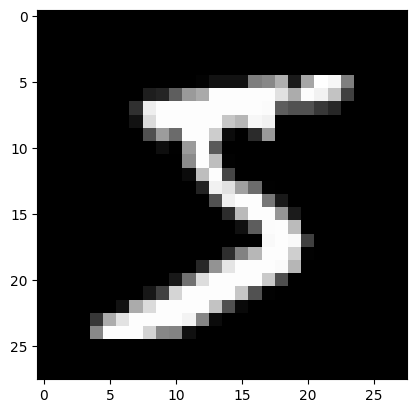

In [231]:
import matplotlib.pyplot as plt
plt.imshow(mnist_train.data[0],cmap='gray');

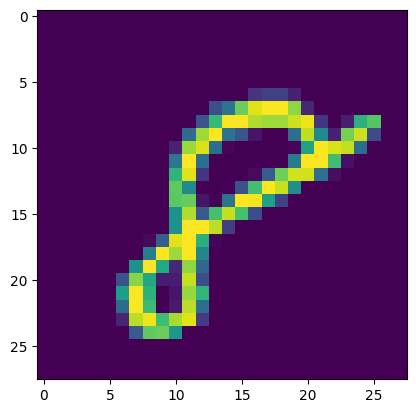

In [232]:
plt.imshow(mnist_train.data[-1]); #The last image

In [233]:
mnist_test.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [234]:
print(mnist_train.data[0].min(),mnist_train.data[0].max())

tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)


### Preprocessing the training data

The original MNIST images are of shape **28 × 28** with pixel values ranging from **0 to 255**.

To prepare the data for model training:

- We ***flatten each image*** from a 2D (28 × 28) matrix into a 1D vector of size **784 (28 × 28)**  
- We ***stack all images as rows*** to form a matrix of shape **(60000, 784)**  
- We ***normalize pixel values*** by dividing by 255 so that all values lie between **0 and 1**

This preprocessing step helps improve training stability and performance.

In [235]:
X_train = mnist_train.data.reshape(60000,784)/255
y_train = mnist_train.targets
X_test = mnist_test.data.reshape(10000,784)/255
y_test = mnist_test.targets

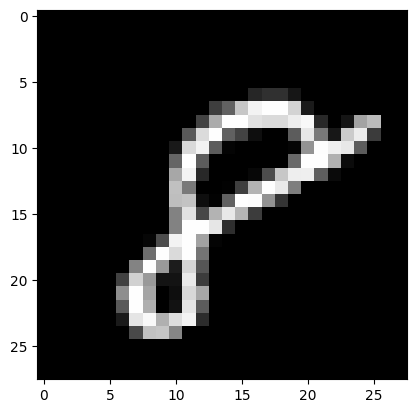

In [236]:
#To see each image you need to reshape it again to pixels
plt.imshow(X_train[-1].reshape(28,28),cmap='gray');

In [237]:
y_train[-1]

tensor(8)

This example shows that the displayed image corresponds to the digit **8**.

### Model objective

Our goal is to build a function that takes the input images and predicts the corresponding digit labels.

In other words, we want to learn a mapping from the input features (pixel values) to the output classes (digits 0–9).

This function will act as our model and will be trained using the dataset.

In [238]:
input_dim = X_train.shape[1]
output_dim = len(torch.unique(y_train))
print(input_dim,output_dim)
print(len(y_train))

784 10
60000


### Explanation

- `y_train` contains labels like: `[0, 1, 2, ..., 9]`
- `torch.unique()` → finds distinct values  
- `len()` → counts them  

### Model formulation

We define a linear model:

$$
h(X) = X W^\top
$$

where:

- $X \in \mathbb{R}^{B \times N}$: input matrix  
- $W \in \mathbb{R}^{K \times N}$: weight matrix  
- $h(X) \in \mathbb{R}^{B \times K}$: output (logits)

---

### Definitions

- $N$: number of input features  
- $K$: number of classes

In [239]:
#W = torch.randn(output_dim,input_dim) * math.sqrt(2/input_dim)
#W = torch.zeros(output_dim,input_dim)

### Weight initialization

We initialize the weight matrix using scaled random values which is better than start with all zero weights:
- This is known as `He initialization`, where weights are drawn from a normal distribution and scaled by $\sqrt{\frac{2}{N}}$, where 
N is the number of input features.

```python
W = torch.randn(output_dim, input_dim) * math.sqrt(2 / input_dim)

In [240]:
from torch.nn import Module,ModuleList,Parameter

In [241]:
class Linear(Module):
    def __init__(self, input_dim, output_dim):
        """
        Initialize a linear layer with Gaussian weights scaled by sqrt(2/input_dim)

        Inputs:
            input_dim : int - input feature dimension
            out_dim : int - output feature dimension 
        """
        super().__init__()
        self.weight = Parameter(torch.randn(output_dim,input_dim) * math.sqrt(2/input_dim))
        #the weights are stored as a Parameter in the class
    def forward(self,X):
        """
        Apply the linear layer to one or more input vectors.

        Input:
            X : torch.Tensor[float] (batch_size * input_dim) - input tensor
        Output:
            torch.Tensor[float] (batch_size * output_dim) - transformed tensor
        """
        return X@self.weight.T

In [242]:
model = Linear(input_dim,output_dim)
logits = model(X_train)

In [243]:
logits.shape

torch.Size([60000, 10])

In [244]:
list(model.parameters()) #One matrix of weights

[Parameter containing:
 tensor([[-0.0357,  0.0110,  0.0063,  ...,  0.0084,  0.0465,  0.0467],
         [-0.0650, -0.0265, -0.0719,  ...,  0.0527,  0.0631, -0.0132],
         [ 0.1092, -0.0243, -0.0204,  ...,  0.0296, -0.0187,  0.0432],
         ...,
         [ 0.0682, -0.0850,  0.0102,  ..., -0.0257,  0.0382,  0.0254],
         [ 0.0234, -0.1307, -0.1159,  ..., -0.0384, -0.0577, -0.0762],
         [-0.0295,  0.0439,  0.0245,  ..., -0.0341,  0.0199, -0.0256]],
        requires_grad=True)]

#### Cross Entropy Loss
Recall that the cross entropy loss is defined, for $\hat{y} \in \mathbb{R}^k$ and $y \in \{1,\ldots,k\}$ as
$$L_{ce}(\hat{y}, y) = -\log \left ( \frac{\exp \hat{y}_y}{\sum_{j=1}^k \exp \hat{y}_j} \right ) = -\hat{y}_y + \log \sum_{j=1}^k \exp \hat{y}_j$$

In [245]:
class CrossEntropyLoss(Module):
    def forward(self, logits, y):
        y_hat_y = logits[torch.arange(len(y)),y]
        #y_hat_y is the logit of it's true class for each image
        self.loss = -y_hat_y + torch.logsumexp(logits,dim=1) #dim=1, as the sum goes over k
        return self.loss.mean()

In [246]:
loss = CrossEntropyLoss()
print(loss(logits, y_train))

tensor(2.3801, grad_fn=<MeanBackward0>)


### Error:

- `logits.argmax(dim=1)` returns the predicted class for each input  

- We compare the predictions with the true labels `y`  

- `(logits.argmax(dim=1) != y)` produces a boolean tensor indicating incorrect predictions  

- `.float().mean()` computes the fraction of misclassified samples

In [247]:
def Error(logits,y):
    return (logits.argmax(dim=1) != y).float().mean()

In [248]:
Error(logits,y_train)

tensor(0.8514)

### Optimization (Stochastic Gradient Descent)

The goal of optimization is to find the best values for the **weights** that minimize the loss on the training set.

The **SGD update rule** is:

$$
w := w - \eta \, \nabla L_\text{CE}(w \cdot x_i, y_i)
$$

Where:

- $w$ → weight matrix  
- $\eta$ → learning rate  (step size)
- $L_\text{CE}$ → cross-entropy loss  
- $(x_i, y_i)$ → a training sample (or mini-batch)

In [249]:
class SGD:
    def __init__(self,parameters,learning_rate):
        """
        Initialize an SGD optimizer over a set of model parameters.

        Inputs:
            parameters: iterable[torch.nn.Parameter] - parameters to optimize
            learning_rate : float - gradient descent step size
        """
        self.parameters = list(parameters)
        #model.parameters() generates an object that produces values one at a time, 
        #and once they are used, they're gone. Therefore we store it in a list so that we
        #can iterate
        self.learning_rate = learning_rate

    def step(self):
        """
        Apply one SGD update to all stored parameters.
        """
        with torch.no_grad(): #parameters update here
            for w in self.parameters:
                if w.grad is not None: 
                    w -= self.learning_rate * w.grad

    def zero_grad(self):
        """
        Zero out gradients for all stored parameters when gradients exists.
        """
        for w in self.parameters:
            if w.grad is not None:
                w.grad.zero_()
                

In [250]:
optimizer = SGD(model.parameters(),0.1) 
optimizer.zero_grad() #First remove the old w.grad
optimizer.step() #Then calculate the new w.grad

In [251]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.0357,  0.0110,  0.0063,  ...,  0.0084,  0.0465,  0.0467],
         [-0.0650, -0.0265, -0.0719,  ...,  0.0527,  0.0631, -0.0132],
         [ 0.1092, -0.0243, -0.0204,  ...,  0.0296, -0.0187,  0.0432],
         ...,
         [ 0.0682, -0.0850,  0.0102,  ..., -0.0257,  0.0382,  0.0254],
         [ 0.0234, -0.1307, -0.1159,  ..., -0.0384, -0.0577, -0.0762],
         [-0.0295,  0.0439,  0.0245,  ..., -0.0341,  0.0199, -0.0256]],
        requires_grad=True)]

### Custom DataLoader

We implement a simple **sequential minibatch data loader** to iterate over the dataset in batches.

How it works:
- The dataset is divided into smaller chunks called ***mini-batches***
- Each batch contains batch_size number of samples
- The loader iterates through the dataset sequentially

```python
class DataLoader():
    ...

In [252]:
class DataLoader():
    def __init__(self, X_full, y_full, batch_size):
        """
        Initialize a simple sequential minibatch data loader.

        Input:
            X : 2D torch.Tensor[float] - (N * n) full input dataset
            y : 1D torch.Tensor[float] - (N elements) full set of desired outputs
            batch_size : int - number of examples / minibatch 
        """
        self.X_full = X_full
        self.y_full = y_full
        self.batch_size = batch_size
        self.N = len(y_full)
    
    def __iter__(self):
        self.idx = 0
        return self
    def __next__(self):
        """ 
        Return the next iteration or raise StopIteration when exhausted.
        """
        if self.idx >= self.N:
            raise StopIteration
        X_batch = self.X_full[self.idx:self.idx+self.batch_size]
        y_batch = self.y_full[self.idx:self.idx+self.batch_size]

        self.idx += self.batch_size

        return X_batch, y_batch


In [253]:
### initialize data loader, where X_full and y_full are complete dataset
loader = DataLoader(X_train,y_train,100)
#for X,y in loader:
    ### X,y contain each sequential minibatches from X_full, y_full

### Optimizing epoch:

This function takes three arguments a model, a loader, a loss, and an optimizer

1 epoch = 1 full pass over all training samples, with parameter updates happening batch by batch. Each epoch starts from the weights learned in the previous epoch

In [254]:
def epoch(model,loader,loss,opt=None):
    total_loss = 0
    total_errors = 0
    total_samples = 0 

    for X_batch, y_batch in loader: ### get the sequential minibatches
        logits = model(X_batch) ### calc the y_pred from our linear model
        batch_loss = loss(logits,y_batch) ### compute the CrossEntropyLoss

        ### Now time for SGD Optimization of the loss
        if opt is not None:
            opt.zero_grad()
            batch_loss.backward() #compute gradients in a computation graph
            opt.step()

        total_loss += batch_loss.item() * len(y_batch)
        total_errors += (logits.argmax(dim=1) != y_batch).sum().item()
        total_samples += len(y_batch)

    avg_loss = total_loss / total_samples
    avg_errors = total_errors / total_samples

    return avg_loss, avg_errors



In [255]:
model = Linear(input_dim,output_dim)
loss = CrossEntropyLoss()
optimizer = SGD(model.parameters(),learning_rate=0.15)
train_dataloader = DataLoader(X_train,y_train,100)
test_dataloader = DataLoader(X_test,y_test,100)
train_losses, train_errors = [], []
test_losses, test_errors = [], []
for i in range(10):
    train_loss, train_err = epoch(model,train_dataloader,loss,optimizer)
    test_loss, test_err = epoch(model,test_dataloader,loss) ### optimizer not included as it's on test dataset
    
    train_losses.append(train_loss)
    train_errors.append(train_err)
    test_losses.append(test_loss)
    test_errors.append(test_err)
    
    print(f"Train Loss: {train_loss:.4f}, Train Error: {train_err:.4f}, "+
          f"Test Loss: {test_loss:.4f}, Test Error: {test_err:.4f}")

Train Loss: 0.4899, Train Error: 0.1294, Test Loss: 0.3481, Test Error: 0.0966
Train Loss: 0.3455, Train Error: 0.0968, Test Loss: 0.3178, Test Error: 0.0881
Train Loss: 0.3231, Train Error: 0.0903, Test Loss: 0.3056, Test Error: 0.0856
Train Loss: 0.3114, Train Error: 0.0870, Test Loss: 0.2989, Test Error: 0.0838
Train Loss: 0.3037, Train Error: 0.0844, Test Loss: 0.2946, Test Error: 0.0831
Train Loss: 0.2982, Train Error: 0.0825, Test Loss: 0.2916, Test Error: 0.0817
Train Loss: 0.2940, Train Error: 0.0811, Test Loss: 0.2894, Test Error: 0.0800
Train Loss: 0.2905, Train Error: 0.0801, Test Loss: 0.2876, Test Error: 0.0797
Train Loss: 0.2876, Train Error: 0.0791, Test Loss: 0.2862, Test Error: 0.0792
Train Loss: 0.2851, Train Error: 0.0782, Test Loss: 0.2850, Test Error: 0.0790


### Training Results and Visualization

We plot the training and test loss and error over epochs to evaluate model performance.

- The loss decreases over time, indicating that the model is learning  
- The error rate also decreases, showing improved prediction accuracy  
- The gap between training and test performance helps assess generalization  

This confirms that the model successfully learns from the data using stochastic gradient descent.

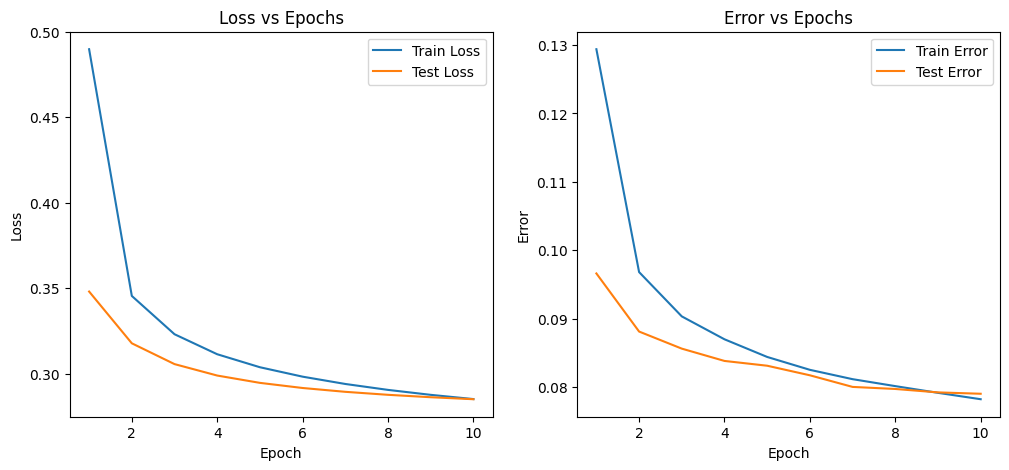

In [256]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

# Error plot
plt.subplot(1,2,2)
plt.plot(epochs, train_errors, label="Train Error")
plt.plot(epochs, test_errors, label="Test Error")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Error vs Epochs")
plt.legend()

plt.show()

Predicted number: 8
True Class: 8


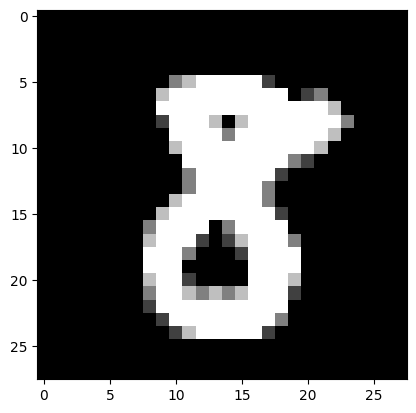

In [257]:
print(f"Predicted number: {model(X_test[-9:-8]).argmax()}")
print(f"True Class: {y_test[-9]}")
plt.imshow(X_test[-9].reshape(28,28), cmap='gray');

### Model prediction on a test sample

We visualize a sample image from the test dataset and compare the model’s prediction with the true label.

- The image is reshaped back to **28 × 28** for visualization  
- The model predicts the class using the highest logit value  
- We compare the predicted label with the ground truth  

In this example:

- **Predicted label:** 8  
- **True label:** 8  

This shows that the model correctly classifies this sample.

### Two-Layer Neural Network

Now, we extend our model to a more expressive architecture by introducing a **two-layer neural network**.

The model is defined as:

$$
h(x) = W_2 \, \sigma(W_1 x)
$$

where:

- $W_1$ → weights of the first (hidden) layer  
- $W_2$ → weights of the second (output) layer  
- $\sigma(\cdot)$ → activation function (ReLU)  

---

### ReLU Activation

The nonlinearity used is the **ReLU (Rectified Linear Unit)** function:

$$
\sigma(z) = \max(0, z)
$$

---

### Intuition

- The first layer ($W_1 x$) learns intermediate features  
- The ReLU introduces **non-linearity**, allowing the model to learn complex patterns  
- The second layer ($W_2$) maps these features to output class scores  

---

### Why this is better than a linear model?

- A single linear layer can only learn **linear decision boundaries**  
- Adding a hidden layer + ReLU enables the model to learn **nonlinear relationships**  

 2/3 of data are in range between (-1.4641540050506592, 1.4641540050506592)


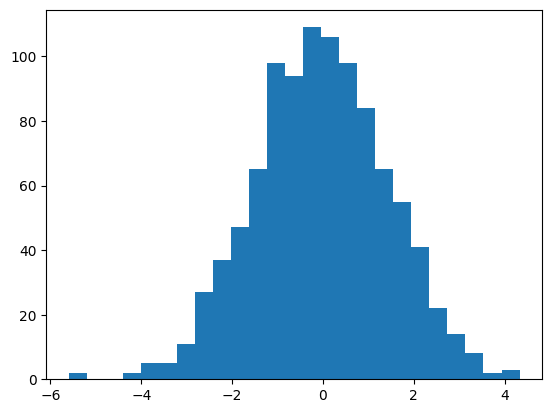

In [258]:
n = 20000
x = torch.randn(n)
w = torch.randn(1000,n)*math.sqrt(2/n)
y = w@x
plt.hist(y, bins=25)
print(f" 2/3 of data are in range between {-y.std().item(),y.std().item()}")

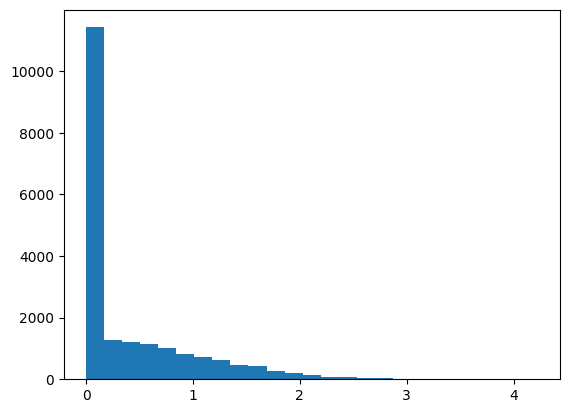

In [259]:
x1 = torch.relu(torch.randn(n))
plt.hist(x1, bins=25);

- The distribution becomes **non-negative** due to ReLU  

- Many values are **zero** (ReLU sparsity)

 2/3 of data are in range between (-0.9577257633209229, 0.9577257633209229)
Now the std is ~ 1


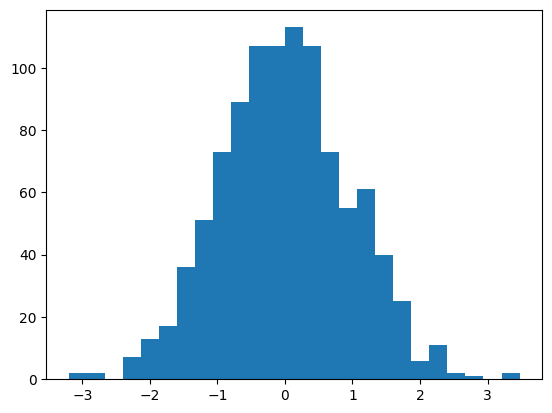

In [260]:
w1 = torch.randn(1000,n)*math.sqrt(2/n)
y1 = w1@x1
plt.hist(y1,bins=25);
print(f" 2/3 of data are in range between {-y1.std().item(),y1.std().item()}")
print("Now the std is ~ 1")

In [261]:
class TwoLayerNN(Module):
    def __init__(self,input_dim,hidden_dim,output_dim):
        """ 
        Initialize a two-layer ReLU neural network
        Inputs:
            input_dim : int - input feature dimension
            hidden_dim : int - hidden layer dimension
            output_dim : int - output feature dimension
        """
        super().__init__()
        self.linear1 = Linear(input_dim,hidden_dim)
        self.linear2 = Linear(hidden_dim,output_dim)

    def forward(self,X):
        """
        Apply 2 linear layers with ReLU between them.
        Input:
            X : torch.Tensor[float] (batch_size * input_dim) - input_tensor
        Output:
            torch.Tensor[float] (batch_size * output_dim) - output logits 
        """
        hidden = torch.relu(self.linear1(X))
        output = self.linear2(hidden)
        return output

In [262]:
model_NN = TwoLayerNN(input_dim,300,output_dim)
optimizer = SGD(model_NN.parameters(),learning_rate=0.15)
loss = CrossEntropyLoss()
for i in range(10):
    train_loss, train_err = epoch(model_NN,train_dataloader,loss,optimizer)
    test_loss, test_err = epoch(model_NN,test_dataloader,loss) ### optimizer not included as it's on test dataset
    
    print(f"Train Loss: {train_loss:.4f}, Train Error: {train_err:.4f}, "+
          f"Test Loss: {test_loss:.4f}, Test Error: {test_err:.4f}")


Train Loss: 0.3592, Train Error: 0.0994, Test Loss: 0.2299, Test Error: 0.0679
Train Loss: 0.1905, Train Error: 0.0543, Test Loss: 0.1639, Test Error: 0.0490
Train Loss: 0.1410, Train Error: 0.0397, Test Loss: 0.1317, Test Error: 0.0393
Train Loss: 0.1128, Train Error: 0.0312, Test Loss: 0.1141, Test Error: 0.0336
Train Loss: 0.0941, Train Error: 0.0261, Test Loss: 0.1022, Test Error: 0.0297
Train Loss: 0.0805, Train Error: 0.0222, Test Loss: 0.0938, Test Error: 0.0279
Train Loss: 0.0701, Train Error: 0.0190, Test Loss: 0.0880, Test Error: 0.0256
Train Loss: 0.0618, Train Error: 0.0168, Test Loss: 0.0838, Test Error: 0.0246
Train Loss: 0.0549, Train Error: 0.0146, Test Loss: 0.0807, Test Error: 0.0247
Train Loss: 0.0492, Train Error: 0.0129, Test Loss: 0.0780, Test Error: 0.0238


### Comparison with Linear Model

Compared to the previous linear model, we observe a **significant improvement** by using a two-layer neural network.

- The added hidden layer allows the model to learn more complex patterns  
- The ReLU activation introduces nonlinearity  
- This results in better performance on the task

Finally, implement an arbitrary multi-layer neural network.  This would represent the multi-layer deep ReLU network
$$ h(x) = W_{L} \sigma(W_{L-1} \sigma ( \ldots W_2 \sigma(W_1 x) \ldots))$$
where $\sigma$ again is the ReLU nonlinearity.

This class is initialized by passing the input and output dimensions, along with list of all hidden dimensions (i.e., the dimensionality of the inner activations in the network).

In [ ]:
class MultiLayerNN(Module):
    def __init__(self, input_dim,hidden_dim,output_dim):
        """
        Initialize a deep ReLU network with arbitary hidden dimensions.
        Inputs:
            input_dim : int - input feature dimension
            hidden_dim : list[int] - hidden layer widths in order
            output_dim : int - output feature dimension
        """
        super().__init__()
        self.linears = ModuleList() ### This is a ModuleList of each Linear module
        dims = [input_dim]+hidden_dim+[output_dim] ### single list of dimension
        for i in range(len(dims)-1):
            self.linears.append(Linear(dims[i],dims[i+1]))

    def forward(self,X):
        """
        Apply all hidden linear layers with ReLU, then final linear output layer.
        Input:
            X : torch.Tensor[float] (batch_size * input_dim) - input tensor
        Output:
            torch.Tensor[float] (batch_size * out_dim) - output logits
        """
        for layer in self.linears[:-1]:
            X = torch.relu(layer(X))
        logits = self.linears[-1](X)
        return logits


In [265]:
model_MLNN = MultiLayerNN(input_dim,[300],output_dim)
optimizer = SGD(model_MLNN.parameters(),learning_rate=0.15)
loss = CrossEntropyLoss()
for i in range(10):
    train_loss, train_err = epoch(model_MLNN,train_dataloader,loss,optimizer)
    test_loss, test_err = epoch(model_MLNN,test_dataloader,loss) ### optimizer not included as it's on test dataset
    
    print(f"Train Loss: {train_loss:.4f}, Train Error: {train_err:.4f}, "+
          f"Test Loss: {test_loss:.4f}, Test Error: {test_err:.4f}")

NotImplementedError: Module [MultiLayerNN] is missing the required "forward" function